In [3]:
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline

# Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC

# Evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, f1_score
import time

import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud

from rital_nlp_project.common.utils import load_clean_data
from rital_nlp_project.common.notebook_utils import init_notebook
from rital_nlp_project.common.models_eval import eval_pipeline, eval_combination_matrix
import rital_nlp_project.common.eda as eda

init_notebook()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
texts_movies, classes_movies = load_clean_data("../Dataset/movies_clean.parquet")

### Models

##### Tested models
- SVM 
- Multinomila Naive Bayes
- Logistic regression

##### Granularity
- Characters
- Tokens of size 3 characters
- Words

In [5]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(texts_movies, classes_movies, random_state=42)

#### Combination matrix

In [6]:
max_features = 5000
min_df = 5
max_df = 0.5
vectorizer_list = [
    CountVectorizer(analyzer="char", ngram_range=(1, 1), max_features=max_features),
    CountVectorizer(analyzer="char_wb", ngram_range=(4, 4), max_features=max_features, min_df=min_df, max_df=max_df),
    CountVectorizer(analyzer="word", ngram_range=(1, 1), max_features=max_features, min_df=min_df, max_df=max_df),
    CountVectorizer(analyzer="word", ngram_range=(1, 3), max_features=max_features, min_df=min_df, max_df=max_df),
    TfidfVectorizer(analyzer="char_wb", ngram_range=(4, 4), max_features=max_features, min_df=min_df, max_df=max_df),

    TfidfVectorizer(analyzer="word", ngram_range=(1, 1), max_features=max_features, min_df=min_df, max_df=max_df),
    TfidfVectorizer(analyzer="word", ngram_range=(1, 3), max_features=max_features, min_df=min_df, max_df=max_df),
]

classifier_list = [
    LogisticRegression(max_iter=100),
    MultinomialNB(), 
    LinearSVC(),
    SVC(kernel="rbf")
]

In [ ]:
results = pd.read_csv("out/baseline_eval_matrix_movies.csv")
#results = eval_combination_matrix(X_train, y_train, X_test, y_test, vectorizer_list, classifier_list)
#results.to_csv("out/baseline_eval_matrix_movies.csv", index=False)

Text(0.5, 1.0, 'Accuracy')

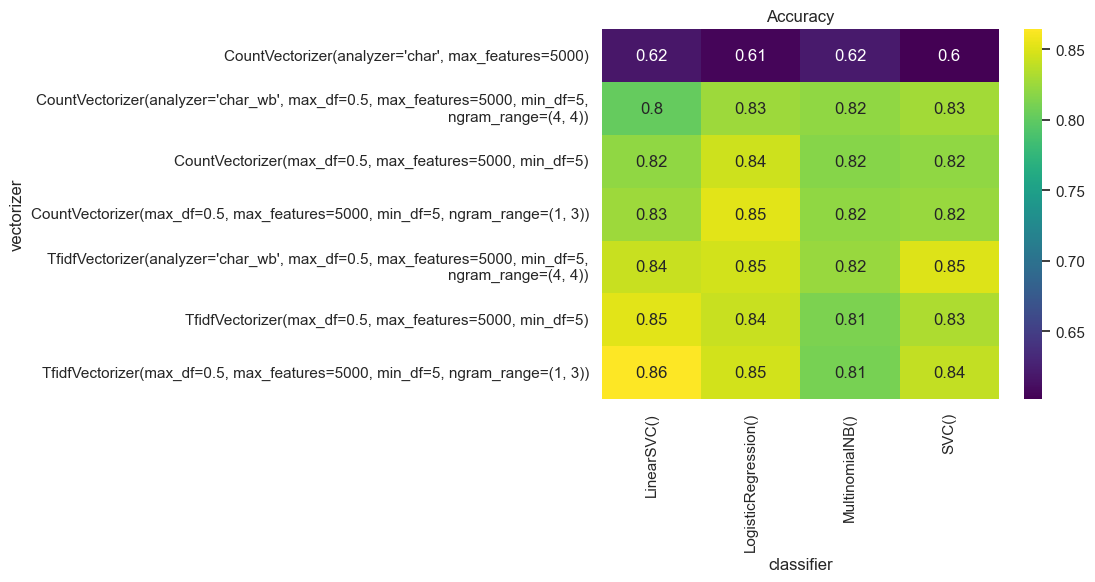

In [12]:
sns.heatmap(results.pivot(columns="classifier", index="vectorizer", values="accuracy"), annot=True, cmap="viridis")
plt.title("Accuracy")

Text(0.5, 1.0, 'F1-score')

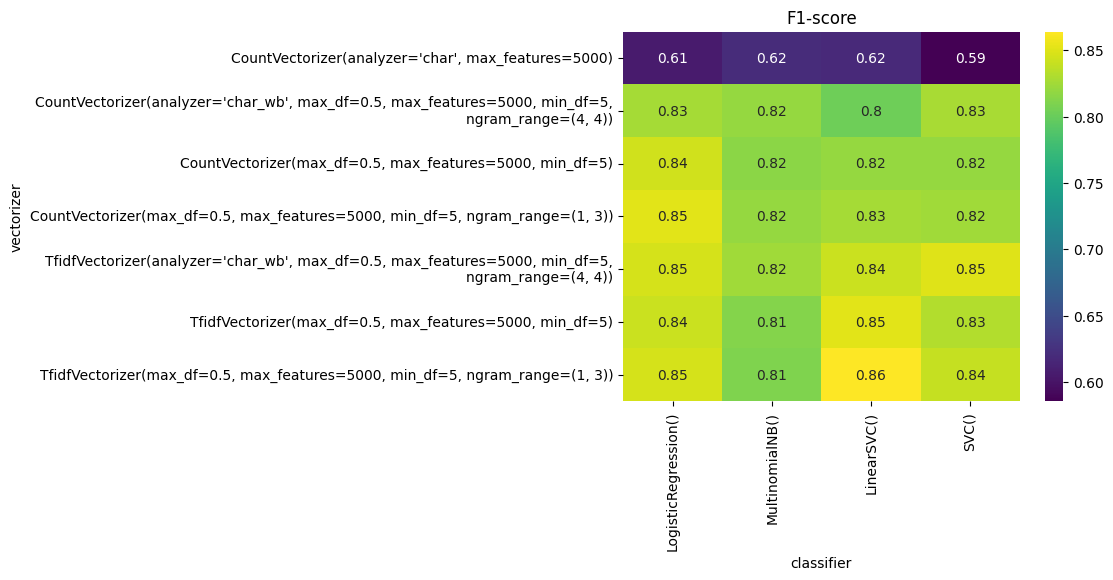

In [21]:
sns.heatmap(results.pivot(columns="classifier", index="vectorizer", values="f1"), annot=True, cmap="viridis")
plt.title("F1-score")

Text(0.5, 1.0, 'Train time')

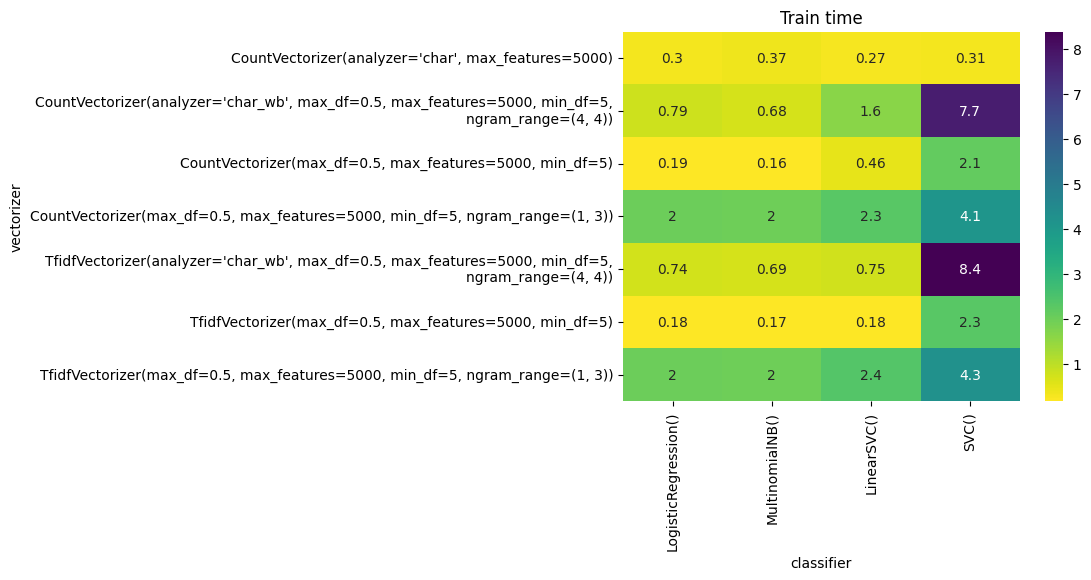

In [22]:
sns.heatmap(results.pivot(columns="classifier", index="vectorizer", values="train_time"), annot=True, cmap="viridis_r")
plt.title("Train time")

#### Separate pipeline eval

In [14]:
pipeline = Pipeline([
    ("vectorizer", CountVectorizer(analyzer="char", ngram_range=(1, 1))),
    ("classifier", MultinomialNB()) 
])
eval_pipeline(X_train, y_train, X_test, y_test, pipeline)

pipeline = Pipeline([
    ("vectorizer", CountVectorizer(min_df=5, max_df=0.5, analyzer="char_wb", ngram_range=(3, 3))),
    ("classifier", MultinomialNB()) 
])
eval_pipeline(X_train, y_train, X_test, y_test, pipeline)

pipeline = Pipeline([
    ("vectorizer", CountVectorizer(min_df=5, max_df=0.5, analyzer="word", ngram_range=(1, 1))),
    ("classifier", MultinomialNB()) 
])
eval_pipeline(X_train, y_train, X_test, y_test, pipeline)

pipeline = Pipeline([
    ("vectorizer", CountVectorizer(min_df=5, max_df=0.5, analyzer="word", ngram_range=(1, 3), max_features=10000)),
    ("classifier", MultinomialNB()) 
])
eval_pipeline(X_train, y_train, X_test, y_test, pipeline)


Pipeline steps:
  vectorizer: CountVectorizer(analyzer='char')
  classifier: MultinomialNB()
Scores : [0.60194175 0.56765677 0.7012987  0.58108108 0.66      ], mean score : 0.6223956591258332
Training time: 0.247 seconds
Inference time: 0.077 seconds
Vocabulary size: 33
Train/test accuracy score: 0.62

Pipeline steps:
  vectorizer: CountVectorizer(analyzer='char_wb', max_df=0.5, min_df=5, ngram_range=(3, 3))
  classifier: MultinomialNB()
Scores : [0.7826087  0.77740864 0.77419355 0.71527778 0.77441077], mean score : 0.7647798868203154
Training time: 0.706 seconds
Inference time: 0.223 seconds
Vocabulary size: 4512
Train/test accuracy score: 0.76

Pipeline steps:
  vectorizer: CountVectorizer(max_df=0.5, min_df=5)
  classifier: MultinomialNB()
Scores : [0.84175084 0.83276451 0.83333333 0.70175439 0.82711864], mean score : 0.8073443420472677
Training time: 0.174 seconds
Inference time: 0.047 seconds
Vocabulary size: 9020
Train/test accuracy score: 0.828

Pipeline steps:
  vectorizer: Cou